In [1]:
import os

# 0. VRAM 파편화 완화 (★ torch를 import 하기 전에 설정해야 적용됨)
#    "reserved but unallocated 2.24 GiB" 처럼 잡아만 두고 못 쓰는 조각을 줄여준다.
#    VRAM 8GB 카드에서 VGG16 미세조정을 돌리려면 이 한 줄이 꽤 도움 됨
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import torch

# 1. 기본 디바이스를 CPU로 원복 (데이터 로더 충돌 방지)
torch.set_default_device("cpu")

# 2. Keras 백엔드 설정
os.environ["KERAS_BACKEND"] = "torch"

import keras

print(
    "🚀 사용 중인 GPU:",
    torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
)
print(f"   VRAM 전체 : {torch.cuda.get_device_properties(0).total_memory/1e9:.2f} GB")


🚀 사용 중인 GPU: NVIDIA GeForce RTX 5060 Ti
   VRAM 전체 : 8.55 GB


### 압축되어 있는 폴더 압축풀기
- data 폴더 안에 있는 animal_small.zip 파일을 압축 해제할 수 있도록 명령 진행

### 이미지 데이터 활용
- 실제 이미지 데이터를 가지고 모델에 학습을 진행
- 이미지 데이터는 그대로 사용할 수는 없고, 픽셀단위로 나눠서 숫자로 변환하는 작업 필요
  - openCV에서 제공하는 read_img
  - tensorflow에서 제공하는 image_dataset_from_directory 등

In [2]:
# 데이터분석에 필요한 라이브러리 불러오기
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 이미지를 수치화하기 위해 폴더에 접근하여 이미지를 읽어올 수 있도록 도와주는 도구 불러오기
from tensorflow.keras.utils import image_dataset_from_directory

# 반복문을 사용할 때 진행상황을 보여주는 도구 불러오기
from tqdm import tqdm

In [3]:
train_img = image_dataset_from_directory(
    # 우리가 읽어올 데이터 경로
    directory='./data/animal/animal_small',
    # 정답데이터를 위해 폴더명을 그대로 정답으로 가져가도록 설정
    # 폴더명 -> 정수 라벨링
    labels='inferred',
    # 다중분류이기 때문에 원핫인코딩을 해야하는데 자동으로 해주도록 설정
    label_mode='categorical',
    # 색상채널 설정 (RGB의 컬러 이미지로 읽기)
    color_mode='rgb',
    # 이미지 사이즈 설정
    # 이미지 크기가 다를 경우에는 학습 할 수 없음 ->동일 크기 가지도록 설정!
    image_size=(224,224)
)

Found 2000 files belonging to 4 classes.


In [4]:
# 문제데이터(X), 정답데이터(y)를 분리하기 위해 직접 집어넣기
X_train = []
y_train = []

# train_img에서 배열값을 뽑아
# 우리가 원하는 img데이터, label데이터를 추출해서 집어넣기
for img, label in train_img.as_numpy_iterator():
  X_train.append(img)
  y_train.append(label)

In [5]:
# 리스트에 담겨있는 정보를 활용하여 배열형태로 넣기
X_train = np.concatenate(X_train)
y_train = np.concatenate(y_train)

In [6]:
# 데이터 크기 확인
X_train.shape, y_train.shape

((2000, 224, 224, 3), (2000, 4))

In [12]:
X_train[0].shape

(224, 224, 3)

### MLP층으로 인공신경망 설계(모델링)

In [6]:
# 도구 불러오기
from tensorflow.keras.models import Sequential # 뼈대
from tensorflow.keras.layers import InputLayer, Dense, Flatten
# 입력층, 중간층(출력층), 1차원으로 만들어주는 도구

In [11]:
# 1. 신경망 구조 설계
# 뼈대 생성
mlp_model = Sequential()
# 입력층 - 입력데이터의 형태에 맞도록!
mlp_model.add(InputLayer(shape=(224,224,3)))

# 1차원으로 평평하게 만들어주는 부분! (flatten)
mlp_model.add(Flatten())

# 중간층1 - 뉴런 64, 활성화함수 relu
mlp_model.add(Dense(units=64, activation='relu'))
# 중간층2 - 뉴런 64, 활성화함수 relu
mlp_model.add(Dense(units=64, activation='relu'))
# 중간층3 - 뉴런 64, 활성화함수 relu
mlp_model.add(Dense(units=64, activation='relu'))

# 출력층 - 다중분류 (범주가 몇개지?)
mlp_model.add(Dense(units=4, activation='softmax'))

# 2. 학습방법 및 평가방법 설정
# 다중분류 -> 손실함수 / 최적화함수:adam / 평가지표 : 정확도
mlp_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# 3. 학습
# 20번 반복학습, 검증용데이터 - 훈련데이터의 20%
h = mlp_model.fit(X_train, y_train,
               epochs=20,
               validation_split = 0.2)




Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 113ms/step - accuracy: 0.2744 - loss: 1583.0785 - val_accuracy: 0.2725 - val_loss: 414.9939
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 114ms/step - accuracy: 0.3231 - loss: 388.1443 - val_accuracy: 0.2375 - val_loss: 812.3886
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - accuracy: 0.3750 - loss: 203.2074 - val_accuracy: 0.2700 - val_loss: 112.9324
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - accuracy: 0.4106 - loss: 98.3990 - val_accuracy: 0.2925 - val_loss: 127.4472
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 106ms/step - accuracy: 0.3375 - loss: 238.9803 - val_accuracy: 0.2400 - val_loss: 373.6320
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - accuracy: 0.3719 - loss: 127.9461 - val_accuracy: 0.3525 - val_loss: 74.6441
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - accuracy: 0.3762 - loss: 62.7721 - val_accuracy: 0.3575 - val_loss: 93.2952
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 5s 105ms/step - accuracy: 0.4187 - loss:

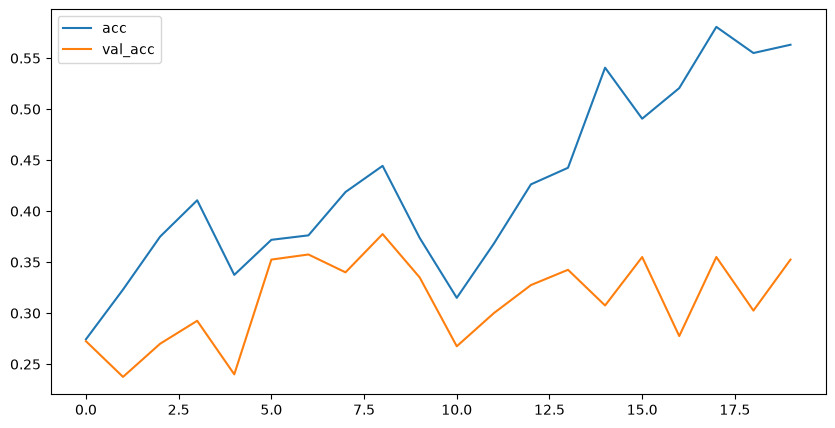

In [12]:
# 4. 결과 시각화
plt.figure(figsize=(10,5))
plt.plot(h.history['accuracy'], label='acc')
plt.plot(h.history['val_accuracy'], label='val_acc')
plt.legend()
plt.show()

### CNN 구조

In [ ]:
# CNN층을 쌓기 위한 도구 불러오기
from tensorflow.keras.layers import Conv2D, MaxPooling2D
# Conv2D : 특징 추출 (돋보기)
# MaxPooling2D : 추출된 특징 중에서도 정말 중요한 특징만 거름(필터,거름망)

In [ ]:
# 1. 신경망 설계(CNN)
# 뼈대 생성
cnn_model = Sequential()

# 입력층
cnn_model.add(InputLayer(shape=(224,224,3)))

# 특성추출부(CNN)
# Conv : 특징 추출하는 층
cnn_model.add(Conv2D(
    # 필터(커널)의 개수 설정
    filters=64,
    # 필터(커널)의 크기 조절 (무조건 홀수로 사용)
    kernel_size=(3,3),
    # 패딩 설정
    # 가장 자리에 중요한 정보가 들어있는 데이터의 경우
    # 패딩 사용하는 것이 유리
    # 하지만 그렇지 않은경우 연산량 때문에 소모 자원이 많아져서 적절하게 사용
    padding='same', # same : 패딩 사용 / valid : 패딩사용x
    # 활성화 함수
    activation='relu',
    # 스트라이드 - 필터를 몇 픽셀씩 건너 뛰면서 특징을 추출할건가요
    strides=(2,2)

))
# Pooling : 중요한 특징만 걸러주는 층
cnn_model.add(MaxPooling2D(pool_size=(2,2)))

# Conv : 특징 추출하는 층
cnn_model.add(Conv2D(
    # 필터(커널)의 개수 설정
    filters=64,
    # 필터(커널)의 크기 조절 (무조건 홀수로 사용)
    kernel_size=(3,3),
    # 패딩 설정
    # 가장 자리에 중요한 정보가 들어있는 데이터의 경우
    # 패딩 사용하는 것이 유리
    # 하지만 그렇지 않은경우 연산량 때문에 소모 자원이 많아져서 적절하게 사용
    padding='same', # same : 패딩 사용 / valid : 패딩사용x
    # 활성화 함수
    activation='relu'
))
# Pooling : 중요한 특징만 걸러주는 층
cnn_model.add(MaxPooling2D())

# Flatten (1차원으로 변환!)
cnn_model.add(Flatten())

# 분류부(MLP)
# 중간층(은닉층)
# 중간층3 - 뉴런 개수 64개, 활성화함수 relu
cnn_model.add(Dense(units=64, activation='relu'))
cnn_model.add(Dense(units=64, activation='relu'))
cnn_model.add(Dense(units=64, activation='relu'))

# 출력층
cnn_model.add(Dense(units=4, activation='softmax'))

In [ ]:
# 2. 학습방법 및 평가방법 설정
cnn_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# 3. 학습
h_cnn = cnn_model.fit(
    X_train, y_train,
    epochs=20,
    validation_split=0.2
)

Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 83ms/step - accuracy: 0.2769 - loss: 7.8822 - val_accuracy: 0.2925 - val_loss: 1.3826
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.3438 - loss: 1.3487 - val_accuracy: 0.3350 - val_loss: 1.3464
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.4581 - loss: 1.1956 - val_accuracy: 0.4150 - val_loss: 1.4855
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.6256 - loss: 0.9149 - val_accuracy: 0.4575 - val_loss: 1.4156
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.7588 - loss: 0.6274 - val_accuracy: 0.4200 - val_loss: 1.9824
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.8419 - loss: 0.4247 - val_accuracy: 0.3925 - val_loss: 2.2116
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9100 - loss: 0.2885 - val_accuracy: 0.3975 - val_loss: 2.6358
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.9306 - loss: 0.1972 - val_accuracy: 0.4200 - v

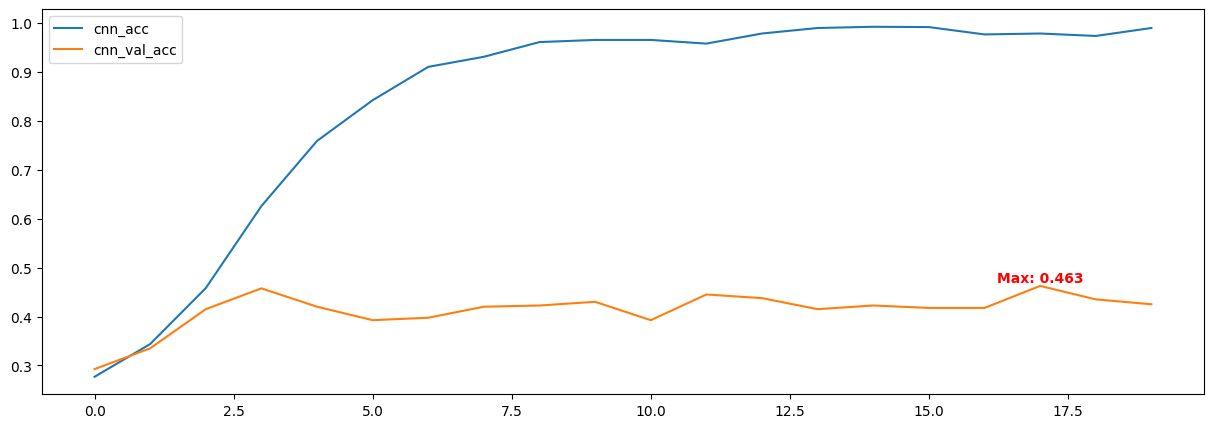

In [ ]:
# 결과 시각화
plt.figure(figsize=(15,5))
plt.plot(h_cnn.history['accuracy'], label='cnn_acc')
plt.plot(h_cnn.history['val_accuracy'], label='cnn_val_acc')

# 검증용 데이터 정확도 숫자 표기하기 코드 (4줄추가)
cnn_val = cnn_model.history.history['val_accuracy']
max_idx = cnn_val.index(max(cnn_val))    # 1. 최대값이 있는 에포크(x축 위치) 구하기
max_val = max(cnn_val)                    # 2. 최대값(y축 위치) 구하기
plt.text(max_idx, max_val + 0.002, f'Max: {max_val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold', color='red') # 3. 최대값 위치에 텍스트 표기

plt.legend()
plt.show()

### 결과 확인
- 일반적인 MLP층을 사용했을 때보다 성능이 개선이 된 것을 볼수 있음
- 이미지 데이터 같은 경우에는 비슷한 형태나 방향, 각도, 위치 등을 맞추기 어렵기 때문에 CNN층과 같이 특성(특징)을 추출할 수 있는 방법을 사용해야 한다
- 현재 결과를 봤을때 Train data에 대해서는 잘 반응을 하지만, validation data에 대해서는 잘 반응하지 못하는 과대적합 현상이 발생
- 데이터의 전처리 또한 과적합에 영향을 줄 수 있음
- 과적합을 방지하기 위해 여러가지 방법을 고려할 수 있음
  - 데이터 추가 수집
  - 데이터 전처리
  - 데이터 증강
  - 신경망층을 깊게 사용
  - epochs 수 증가 등
  

### 실습 : CNN알고리즘을 활용해서 동물 분류 실습
- 내가 직접 CNN층을 이용하여 모델을 설계해보자!


### 전이학습
- 다른 데이텅셋으로 이미 잘 학습되어 있는 모델을 이용하여 내 데이터에 맞게끔 재학습을 진행하는 방법으로, 데이터가 충분하지 않거나 학습할 때 자원이 부족한 경우에 사용
  - 특성추출 방식
  - 미세조정 방식

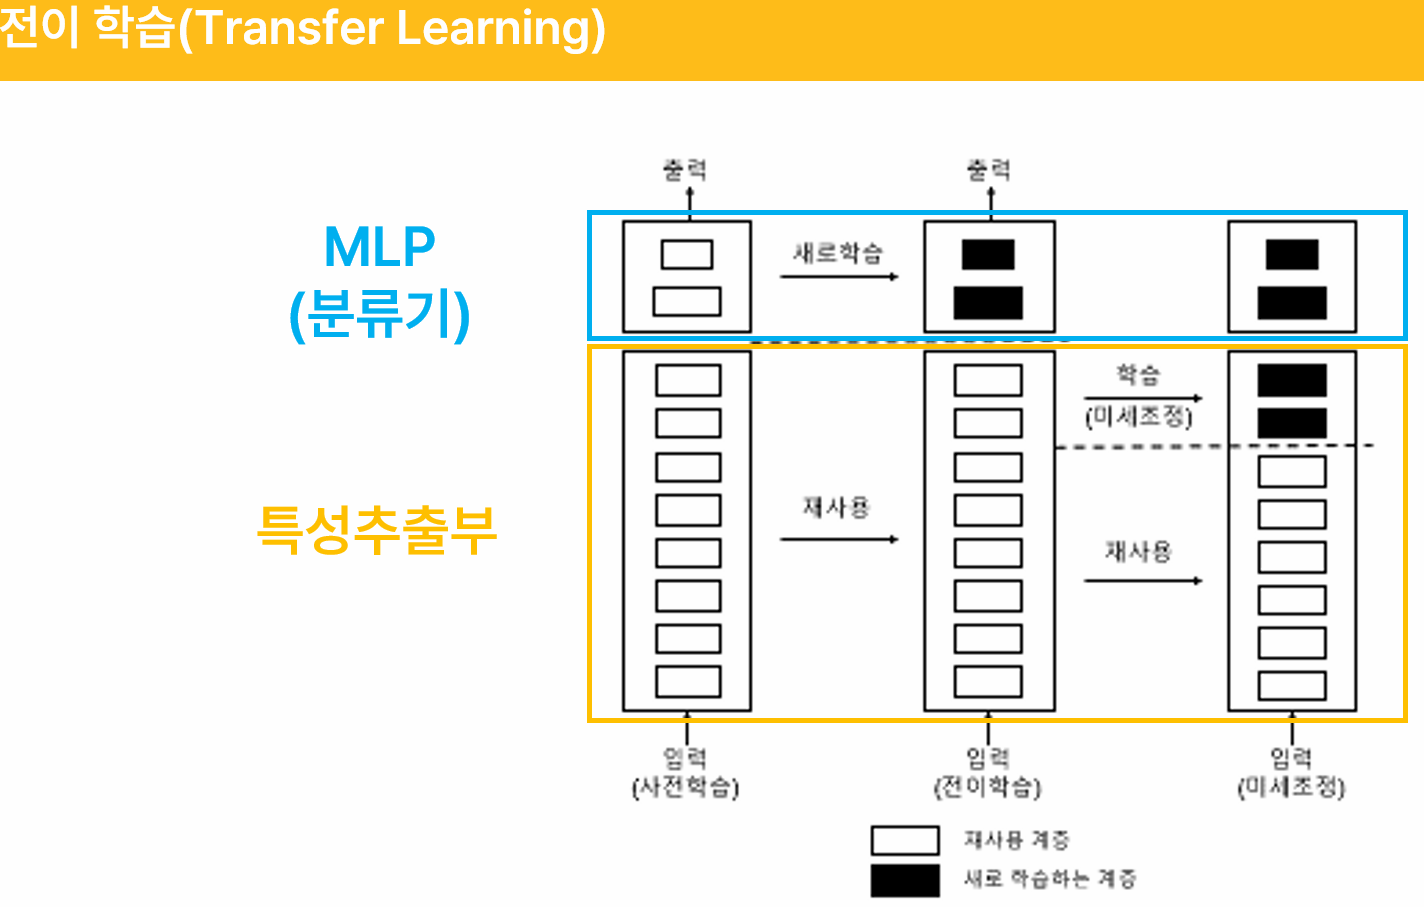

### 특성추출방식(Feature Extraction)
- CNN층의 특성추출부 전체를 가져와서 사용하는 방식
- 분류부(MLP층)만 내 데이터에 맞도록 다시 설계하여 사용하는 방법
- 사전학습된 데이터와 내가 학습할 데이터의 특징이 어느정도 맞아야 좋은 성능을 기대할 수 있음
- 만약에 사전학습된 데이터의 특징이 너무나 다를 경우에는 CNN층을 그대로 사용했을 때 원하는 성능이 안 나올 수 있음

### 미세조정방식(Fine Tunning)
- 기존에 학습된 모델을 기반으로, 내 데이터에 맞도록 가중치 일부를 미세하게 조정하는 방식으로 내 데이터에 최대한 잘 반응하도록 학습하는 방식
- CNN층의 일부분을 나의 데이터셋에 맞도록 새로 학습시켜 사용하는 방법

### 목표
- CNN모델을 사용해서 분류했던 동물데이터를 가지고 전이학습을 하여 성능 개선을 해보자
- 특성추출방식과 미세조정방식을 모두 사용하면서 전이학습을 진행해보자


### VGG16 모델 사용
- CNN 아키텍처를 획기적인 객체 인식 모델을 기반으로 하여 ImageNet이라는 방대한 데이터셋을 가지고 높은 정확도를 보이는 모델
- 13개 Convolution Layer와 3개의 Fully Connected Layer로 구성된 모델
- 모든 Convolution Layer의 커널의 크기는 (3,3)으로 되어 있으며, activation은 relu를 사용한 모델
- 입력 이미지를 사용할 때 (224,224,3)으로 되어 있는 컬러 이미지를 사용한 모델

In [6]:
# VGG16모델 가져오기
from tensorflow.keras.applications import VGG16

In [7]:
# VGG16모델 다운로드(모델을 사용하기 위한 내부 구조 설정)
vgg16 = VGG16(
    # MLP층을 사용하지 않도록 설정
    # (특성추출부만 가지고 올것임 -> 우리 데이터에 맞도록 직접 설계하기 위해)
    include_top = False,
    # 가중치(w) 설정 (imagenet으로 학습되었던 가중치 불러오기)
    weights='imagenet',
    # 입력데이터 설정(이미지의 크기 설정)
    input_shape=(224,224,3)
)

c:\Users\smhrd\AppData\Local\Programs\Python\Python311\Lib\site-packages\torch\utils\_device.py:116: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:39.)
  return func(*args, **kwargs)


### 동결설정
- 우리가 가져온 CNN층은 ImageNet이라는 거대 데이터를 가지고 학습한 모델이다.
- 그런데 우리 데이터가 CNN층을 지나갈 때 학습이 일어나버리면 거대 데이터셋으로 학습된 정보가 사라지기 때문에 모델을 가져와 사용하는 의미가 없어져 버린다.
- 이런 일이 일어나지 않도록 데이터가 CNN층을 지나갈 때 추가적인 학습이 일어나지 않도록 설정하는 것이 동결설정이다. (가중치가 변화되지 않도록 설정)
  - trainable(학습여부)=False 설정

In [9]:
# 동결설정
vgg16.trainable = False

In [8]:
# 신경망 설계를 위한 도구 불러오기
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Dense, Flatten, Conv2D, MaxPooling2D

In [17]:
# 1. 신경망 구조 설계
# 전이학습(특성추출방식) 진행

# 뼈대 생성
transfer_model = Sequential()

# 특성추출부(cnn) ->vgg16
# vgg16에는 입력층 포함 -> 입력층은 우리가 만들지x
transfer_model.add(vgg16)

# Flatten
transfer_model.add(Flatten())

# 분류부(MLP)---------------
# 중간층
transfer_model.add(Dense(units=64, activation='relu'))
transfer_model.add(Dense(units=128, activation='relu'))
transfer_model.add(Dense(units=64, activation='relu'))

# 출력층
transfer_model.add(Dense(units=4, activation='softmax'))


# 2. 학습방법 및 평가방법 설정
transfer_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# 3. 학습
h_transfer = transfer_model.fit(
    X_train, y_train,
    epochs=20,
    validation_split=0.2
)

Epoch 1/20
 8/50 ━━━━━━━━━━━━━━━━━━━━ 51s 1s/step - accuracy: 0.3778 - loss: 8.4105

KeyboardInterrupt: 

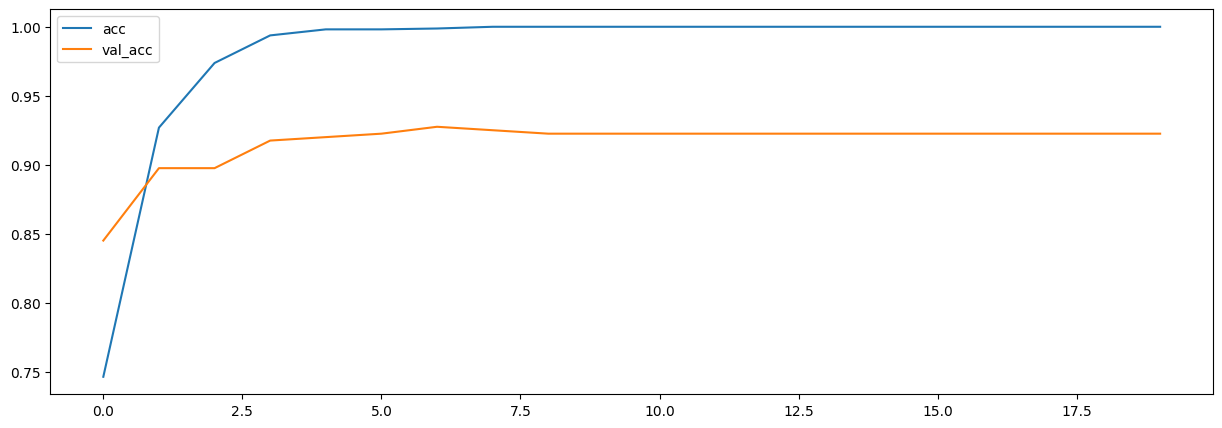

In [19]:
# 학습 결과 시각화
plt.figure(figsize=(15,5))
plt.plot(h_transfer.history['accuracy'], label='acc')
plt.plot(h_transfer.history['val_accuracy'], label='val_acc')
plt.legend()
plt.show()

### 미세조정 방식
- 특성추출부(CNN)의 하단의 일부분의 층을 내 데이터로 학습을 진행하여 가중치를 변화시켜 사용하는 방법

In [21]:
# 미세조정 방식을 사용하기 위해 vgg16을 구성하는 각 층의 이름을 확인하기
# enumerate() : 길이가 있는 데이터(리스트, 튜플)에 대해서 index값을 생성해주는 기능
# model.layers : 각 층의 정보를 확인하는 기능
for index, layer in enumerate(vgg16.layers) :
  print(index, layer.name)

0 input_layer
1 block1_conv1
2 block1_conv2
3 block1_pool
4 block2_conv1
5 block2_conv2
6 block2_pool
7 block3_conv1
8 block3_conv2
9 block3_conv3
10 block3_pool
11 block4_conv1
12 block4_conv2
13 block4_conv3
14 block4_pool
15 block5_conv1
16 block5_conv2
17 block5_conv3
18 block5_pool


### VGG16 층 확인
- vgg16층의 정보를 확인했을때, block5층에 대한 CNN층은 우리 데이터로 학습을 진행하도록 설정하고(동결해제), 나머지 층은 그대로 동결설정을 하도록 진행

In [20]:
import gc, torch
for name in ['mlp_model', 'cnn_model', 'transfer_model']:
    if name in globals():
        del globals()[name]      # 학습곡선 h, h_cnn, h_transfer는 시각화용이라 남김
gc.collect()
torch.cuda.empty_cache()
print(f"GPU 여유 : {torch.cuda.mem_get_info()[0]/1e9:.2f} GB")

GPU 여유 : 6.76 GB


In [22]:
# 미세조정 설정
# 모든 층을 다 학습하도록 설정(동결 해제)
vgg16.trainable = True

# 처음부터 block4까지 (14번 인덱스를 가진 층까지)는 동결 설정
for layer in vgg16.layers[:15] :
  # 각 층에 대해 동결설정
  layer.trainable = False

In [11]:
from tensorflow.keras.optimizers import Adam

In [12]:

import gc, torch, keras

class GCCallback(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        gc.collect()
        torch.cuda.empty_cache()

In [15]:
# 1. 신경망 구조 설계

# 뼈대 생성
transfer_model2 = Sequential()

# 특성추출부 - 입력층 포함
transfer_model2.add(vgg16)

# 1차원으로 변환
transfer_model2.add(Flatten())

# 분류부(MLP) - 중간층3 (64,128,64 활성화함수 relu)
transfer_model2.add(Dense(units=64, activation='relu'))
transfer_model2.add(Dense(units=128, activation='relu'))
transfer_model2.add(Dense(units=64, activation='relu'))

# 출력층
transfer_model2.add(Dense(units=4, activation='softmax'))

# 2. 학습방법 및 평가방법 설정
transfer_model2.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=1e-5),
    metrics=['accuracy']
)

# 3. 학습
h_transfer2 = transfer_model2.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    callbacks=[GCCallback()]
)

Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 139ms/step - accuracy: 0.3406 - loss: 3.3277 - val_accuracy: 0.4625 - val_loss: 1.6924
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 134ms/step - accuracy: 0.6925 - loss: 0.8438 - val_accuracy: 0.5400 - val_loss: 1.4458
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 137ms/step - accuracy: 0.9100 - loss: 0.3156 - val_accuracy: 0.5725 - val_loss: 1.3570
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 146ms/step - accuracy: 0.9775 - loss: 0.1438 - val_accuracy: 0.5975 - val_loss: 1.3119
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 142ms/step - accuracy: 0.9956 - loss: 0.0811 - val_accuracy: 0.6100 - val_loss: 1.2915
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 140ms/step - accuracy: 0.9981 - loss: 0.0541 - val_accuracy: 0.6150 - val_loss: 1.2804
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 143ms/step - accuracy: 0.9987 - loss: 0.0385 - val_accuracy: 0.6250 - val_loss: 1.2689
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 152ms/step - accuracy: 0.9994 - loss: 0.0279 - val_accuracy: 0.

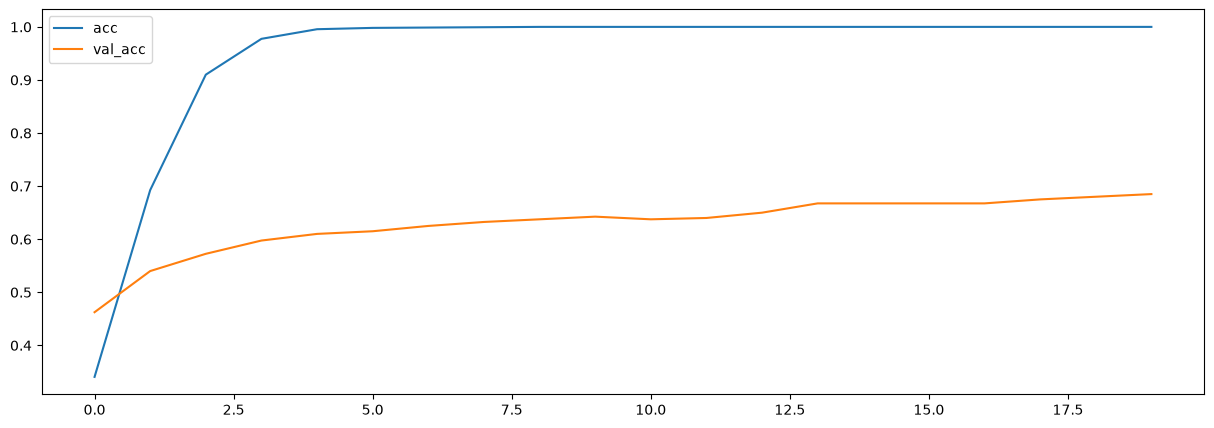

In [16]:
# 결과 시각화
plt.figure(figsize=(15,5))
plt.plot(h_transfer2.history['accuracy'], label='acc')
plt.plot(h_transfer2.history['val_accuracy'], label='val_acc')
plt.legend()
plt.show()

### ResNet 실습
- 2015년에 ILSVRC(ImageNet Large Scale Visual Recognition Challenge) 에서 우승한 CNN 네트워크
- 마이크로소프트에서 개발한 알고리즘



In [14]:
# Resnet 모델 불러오기
from tensorflow.keras.applications import ResNet50V2

# Resnet 모델 다운로드
res50 = ResNet50V2(
    include_top = False, # MLP층 사용X 특성추출부(CNN) 사용O
    weights='imagenet',
    input_shape=(224,224,3)
)

In [ ]:

import gc, torch, keras

class GCCallback(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        gc.collect()
        torch.cuda.empty_cache()

In [15]:
# [1] 특성추출방식
# 1) 특성추출방식을 사용하기 위해서 모든 층 동결설정
res50.trainable = False

# 2) 신경망모델 설계
# 뼈대 생성
resnet_model = Sequential()
# resnet 모델 특성추출부 추가
resnet_model.add(res50)
# 1차원으로 변환
resnet_model.add(Flatten())
# 분류부(MLP) - 중간층3 (64,128,64 , 활성화함수 relu)
resnet_model.add(Dense(units=64, activation="relu"))
resnet_model.add(Dense(units=128, activation="relu"))
resnet_model.add(Dense(units=64, activation="relu"))
# 출력층
resnet_model.add(Dense(units=4, activation="softmax"))
# 3) 학습방법 및 평가방법 설정
resnet_model.compile(
    loss="categorical_crossentropy",
    optimizer=Adam(learning_rate=1e-5),
    metrics=['accuracy']
)
# 4) 학습 - 반복학습횟수 20번, 검증용데이터는 훈련데이터의 20%
h_resnet = resnet_model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    callbacks=[GCCallback()]
)


Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 146ms/step - accuracy: 0.3406 - loss: 9.4303 - val_accuracy: 0.2825 - val_loss: 9.7098
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 165ms/step - accuracy: 0.3344 - loss: 9.6036 - val_accuracy: 0.3825 - val_loss: 8.7153
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 214ms/step - accuracy: 0.4031 - loss: 8.1043 - val_accuracy: 0.4500 - val_loss: 7.3067
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 136ms/step - accuracy: 0.4563 - loss: 7.3850 - val_accuracy: 0.4475 - val_loss: 6.9641
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 157ms/step - accuracy: 0.4831 - loss: 6.6218 - val_accuracy: 0.4700 - val_loss: 6.5000
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 8s 153ms/step - accuracy: 0.5138 - loss: 6.1850 - val_accuracy: 0.4200 - val_loss: 7.9750
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 148ms/step - accuracy: 0.4650 - loss: 7.4055 - val_accuracy: 0.4325 - val_loss: 7.6545
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 139ms/step - accuracy: 0.4906 - loss: 7.0316 - val_accuracy: 0

In [16]:
# [2] 미세조정방식
# 1) 모든 층에 대해서 동결 해제
res50.trainable = True
# 2) 처음부터 180번 인덱스를 가진 층까지는 동결 / 181번인덱스부터 마지막 층 동결 해제
for layer in res50.layers[:181]:
    layer.trainable = False
# 뼈대 생성
resnet_model2 = Sequential()
# resnet 모델 특성추출부 추가
resnet_model2.add(res50)
# 1차원으로 변환
resnet_model2.add(Flatten())
# 분류부(MLP) - 중간층3 (64,128,64 , 활성화함수 relu)
resnet_model2.add(Dense(units=64, activation="relu"))
resnet_model2.add(Dense(units=128, activation="relu"))
resnet_model2.add(Dense(units=64, activation="relu"))
# 출력층
resnet_model2.add(Dense(units=4, activation="softmax"))
# 3) 학습방법 및 평가방법 설정
resnet_model2.compile(
    loss="categorical_crossentropy",
    optimizer=Adam(learning_rate=1e-5),
    metrics=['accuracy']
)
# 4) 학습 - 반복학습횟수 20번, 검증용데이터는 훈련데이터의 20%
h_resnet2 = resnet_model2.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=20,
    callbacks=[GCCallback()]
)



Epoch 1/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 7s 145ms/step - accuracy: 0.3438 - loss: 1.3501 - val_accuracy: 0.3650 - val_loss: 1.3422
Epoch 2/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 24s 495ms/step - accuracy: 0.4775 - loss: 1.2136 - val_accuracy: 0.4300 - val_loss: 1.2369
Epoch 3/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 18s 372ms/step - accuracy: 0.5763 - loss: 1.1024 - val_accuracy: 0.5200 - val_loss: 1.1712
Epoch 4/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 27s 555ms/step - accuracy: 0.6481 - loss: 0.9831 - val_accuracy: 0.5650 - val_loss: 1.1128
Epoch 5/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 209ms/step - accuracy: 0.7013 - loss: 0.8843 - val_accuracy: 0.5900 - val_loss: 1.0885
Epoch 6/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 27s 553ms/step - accuracy: 0.7631 - loss: 0.7923 - val_accuracy: 0.5875 - val_loss: 1.0512
Epoch 7/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 22s 451ms/step - accuracy: 0.7944 - loss: 0.7142 - val_accuracy: 0.5750 - val_loss: 1.0221
Epoch 8/20
50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 426ms/step - accuracy: 0.8288 - loss: 0.6412 - val_accur

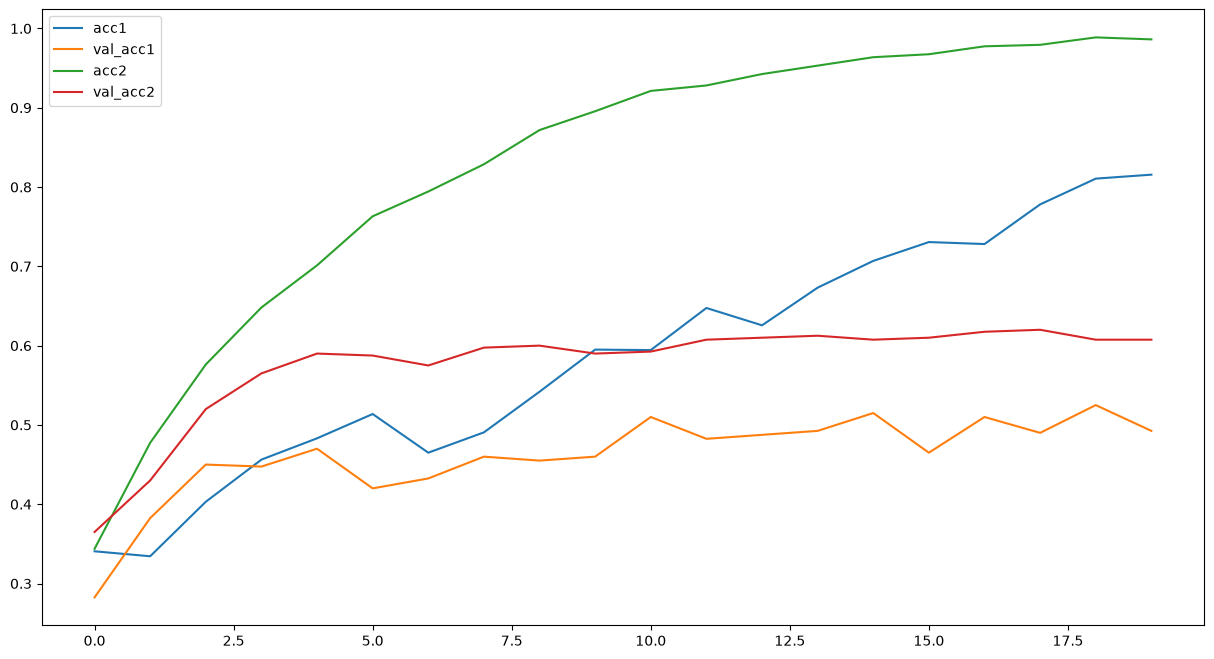

In [18]:
# 6) 결과시각화 (특성추출방식 acc, val_acc / 미세조정방식 acc, val_acc)
# 결과 캡처해서 단톡방에 공유해주세요~
plt.figure(figsize=(15, 8))
plt.plot(h_resnet.history["accuracy"], label="acc1")
plt.plot(h_resnet.history["val_accuracy"], label="val_acc1")
plt.plot(h_resnet2.history["accuracy"], label="acc2")
plt.plot(h_resnet2.history["val_accuracy"], label="val_acc2")
plt.legend()
plt.show()


### 결과 정리
- VGG16, ResNet 모델을 돌려봤을때 어떤 모델은 미세조정방식이 결과가 더 좋고, 어떤 모델은 특성추출방식이 더 결과가 좋았다.
- 이처럼 데이터별로 또는 모델별로 같은 방법으로 돌리더라도 결과가 달라지기 때문에 여러번의 학습을 통해 모델별로 서로 비교하여 최적의 모델을 찾아나가야 한다.
- 또한 데이터를 많이 확보할수록 성능 측면에서 유리할 가능성이 있기 때문에 데이터를 많이 확보하는 것이 좋다.
- 과적합이 일어난 것으로 보일 때는 여러가지 요소를 분석하여 과적합을 줄여나가야 한다.

### 과적합을 줄이는 방법 알아보기
- 학습조기종료(early stopping)
  - 과대적합이 일어나기 전에 모델학습을 중단하여 과대적합을 방지하는 방법으로, 더이상 성능 향상이 이뤄지지 않을 시 학습을 종료하는 방법
- 드롭아웃(drop out)
  - 복잡한 신경망을 가지고 있을 때 퍼셉트론(뉴런)의 일부분을 비활성화시켜 과대적합을 방지하는 방법으로, 모델의 복잡성을 낮춰주는 역할
- 데이터 증강(data augmentation)
  - 데이터가 부족하여 일어나는 현상을 막기 위해 원본데이터와 비슷한 데이터를 생성하여 폭넓은 학습을 할 수 있도록 설정하는 방법(데이터 부족현상 해결)
  - 이미지 증강 : 색상채널 변경, 명암 조절, 방향 변경, 확대, 축소, 좌우반전, 상하반전 등의 방법을 통해 원본이미지와 유사하지만 조금 다른 이미지를 만드는 방법으로 , 데이터 증강 방법 중 하나